In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import diffxpy.api as de
import warnings
import re
warnings.filterwarnings("ignore")

def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = [bind.get(itm, None) for itm in a]  # None can be replaced by any other "not in b" value
    result = [result, [not x is None for x in result]]
    return result

sc.set_figure_params(dpi = 80)

In [ ]:
# General function for running differential gene expression analysis
def run_diffxpy(adata, query_cells, name_reference, name_query, min_cells = 20, reference_cells = [], cell_filtering = []):
    if len(reference_cells) == 0:
        reference_cells = np.logical_not(query_cells)
    if len(cell_filtering) == 0:
        cell_filtering = np.logical_or(query_cells, reference_cells)
    adata.obs['factor_to_test'] = ['G2' if x else 'G1' for x in query_cells]
    adata_sub = adata[cell_filtering,:].copy()

    gene_filter = (adata_sub.X > 0).sum(axis=0) > min_cells
    adata_sub = adata_sub[:,gene_filter].copy()

    sub_output_file = output_prefix % (name_query, name_reference, "%s", "%s")
    
    # Run differential gene expression without using batch as covariate
    formula="~1 + factor_to_test"
    output_file = sub_output_file % ("False", "False")
    if(np.logical_not(os.path.exists(os.path.join(output_path, output_file)))):
        print(output_file)
        test = de.test.wald(data=adata_sub, formula_loc=formula, factor_loc_totest='factor_to_test')
        test.summary().to_csv(os.path.join(output_path, output_file))

    output_file = sub_output_file % ("True", "False")
    if(np.logical_not(os.path.exists(os.path.join(output_path, output_file)))):
        print(output_file)
        test = de.test.wald(data=adata_sub, formula_loc=formula, factor_loc_totest='factor_to_test', as_numeric = adata_sub.obs['size_factor'].to_list())
        test.summary().to_csv(os.path.join(output_path, output_file))

In [ ]:
# Read adata
adata = sc.read_h5ad("../data/Reyes_FLEX_SUBSET_TAM_all__integrated.h5ad")
adata.layers['log1p'] = adata.X.copy()
adata.X = adata.layers['cellbender'].copy()


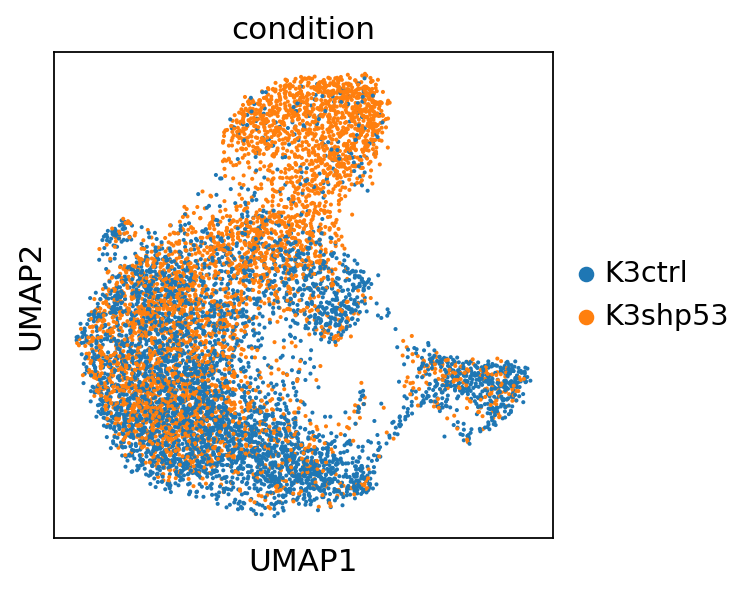

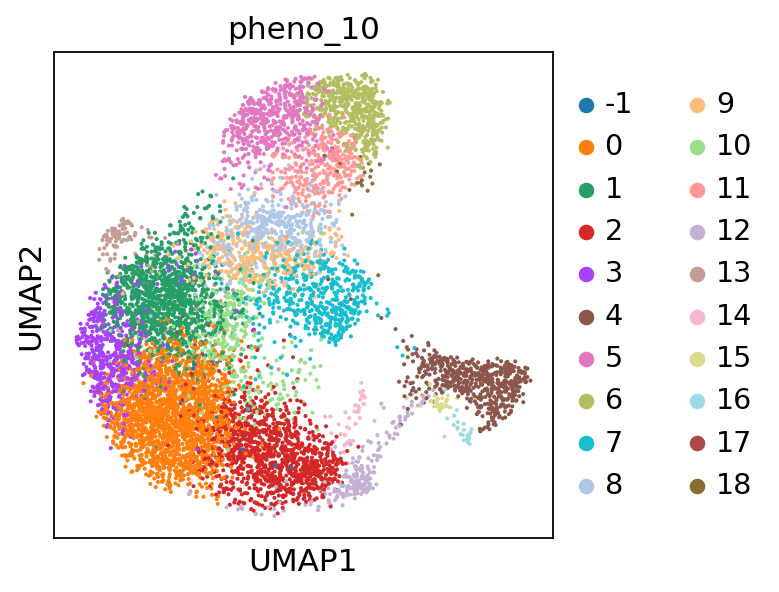

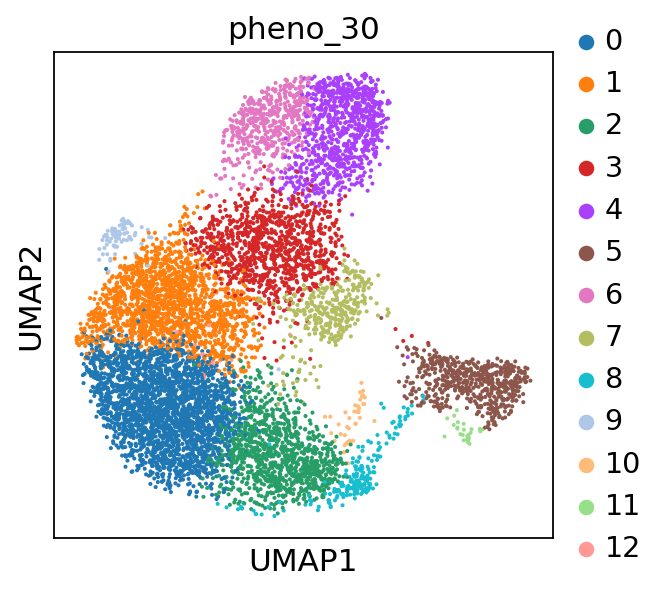

In [ ]:
adata.obs['pheno_10'] = pd.Categorical(adata.obs['pheno_10'])
adata.obs['pheno_30'] = pd.Categorical(adata.obs['pheno_30'])
sc.pl.umap(adata, color='condition')
sc.pl.umap(adata, color='pheno_10')
sc.pl.umap(adata, color='pheno_30')

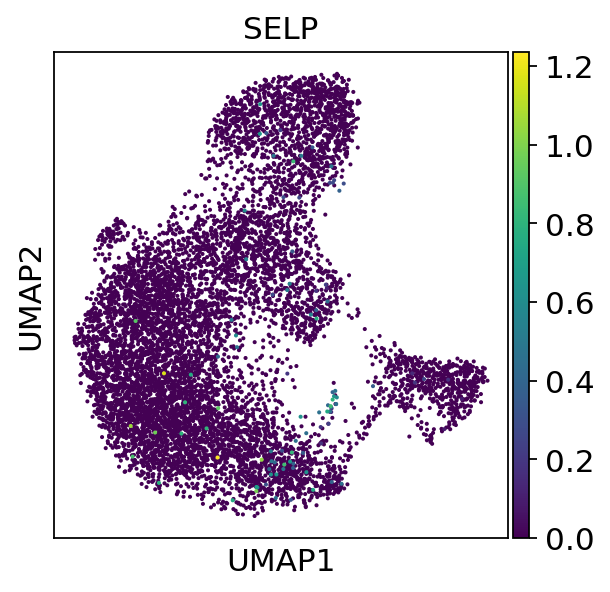

In [ ]:
sc.pl.umap(adata, color='SELP', layer = 'log1p')

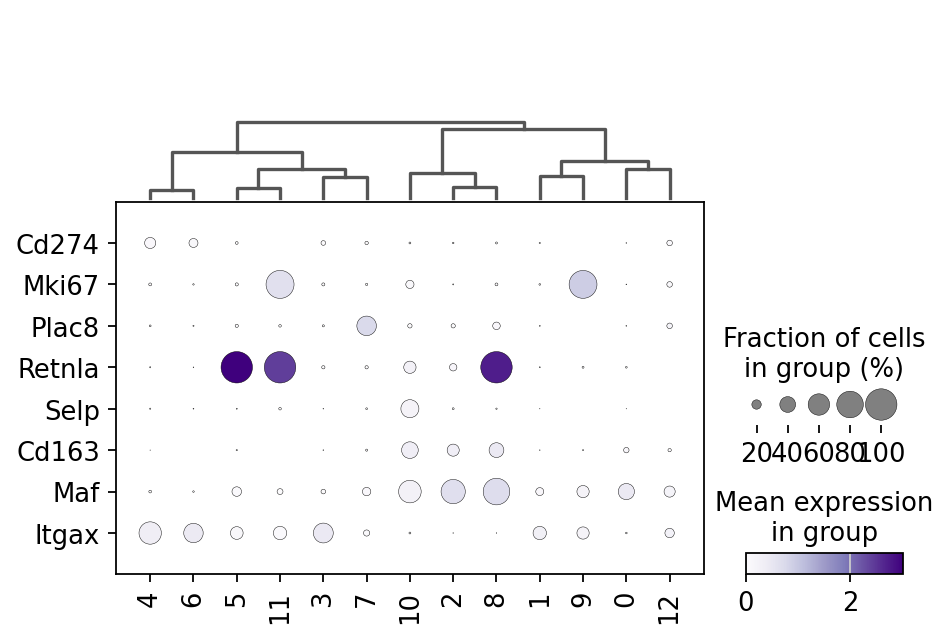

In [ ]:
adata_temp = adata.copy()
adata_temp.var_names = [x.capitalize() for x in adata_temp.var_names]
sc.pl.dotplot(
    adata_temp, groupby = 'pheno_30', 
    var_names = ['Cd274', 'Mki67', 'Plac8', 'Retnla', 'Selp', 'Cd163', 'Maf', 'Itgax'], 
    cmap = 'Purples', swap_axes=True, layer = 'log1p', dendrogram = True
)

In [ ]:
cell_type = np.array(['undefined'] * adata.n_obs, dtype = 'object')
cell_type[ismember(adata.obs['pheno_30'], [4,6])[1]] = 'TAM_Cd274'
cell_type[ismember(adata.obs['pheno_30'], [9])[1]] = 'TAM_cycling'
cell_type[ismember(adata.obs['pheno_30'], [7])[1]] = 'TAM_Plac8'
cell_type[ismember(adata.obs['pheno_30'], [5,11])[1]] = 'TAM_Retnla'
cell_type[ismember(adata.obs['pheno_30'], [8])[1]] = 'TAM_Cd163_Retnla'
cell_type[ismember(adata.obs['pheno_30'], [10])[1]] = 'TAM_Selp'
cell_type[ismember(adata.obs['pheno_30'], [2])[1]] = 'TAM_Cd163'
cell_type[ismember(adata.obs['pheno_30'], [0])[1]] = 'TAM_Maf'
cell_type[ismember(adata.obs['pheno_30'], [1])[1]] = 'TAM_Maf_Itgax'
cell_type[ismember(adata.obs['pheno_30'], [3])[1]] = 'TAM_Itgax'
adata.obs['cell_type'] = cell_type.copy()
adata.obs.to_csv(re.sub('.h5', '.csv', "../data/Reyes_FLEX_SUBSET_TAM_all__integrated.h5ad"))

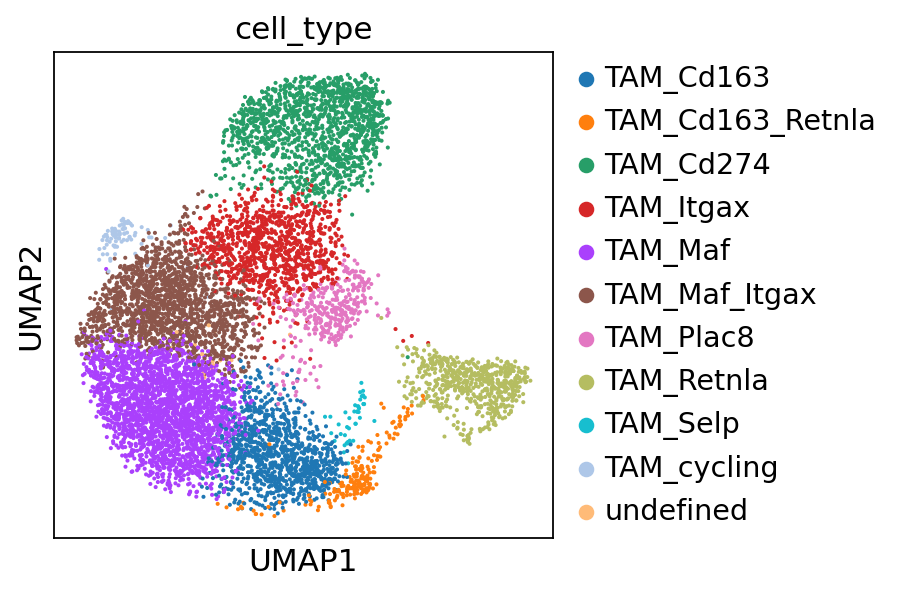

In [ ]:
sc.pl.umap(adata, color='cell_type')